#Modelado de tópicos con BERTopic y sentimientos

In [6]:
!pip install bertopic sentence-transformers --quiet


[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
import pandas as pd
import numpy as np
import re
import html
import matplotlib.pyplot as plt
import seaborn as sns
import string
import warnings
warnings.filterwarnings('ignore')

from bertopic import BERTopic
from sentence_transformers import SentenceTransformer
from umap import UMAP

C:\Users\PC\AppData\Roaming\Python\Python313\site-packages\pandas\core\computation\expressions.py:23: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


In [2]:
df = pd.read_csv("../Preprocesamiento/training_limpio.csv")

In [3]:
# Construimos una función de limpiezan
def limpieza_topicos(text):
    text = html.unescape(text)    # Corrige &amp; &quot; &lt; etc.  
    text=text.lower() #Minúsculas
    text=re.sub(r"http\S+|www\S+", "", text) #Eliminados URL
    text = re.sub(r"@\w+", "", text) #Eliminados Menciones 
    text = re.sub(r"#", "", text) #Eliminados el numeral # pero dejando el contenido de hashtag
    text = re.sub(r"\d+", "", text) #Eliminamos números
    text = text.translate(str.maketrans("", "", string.punctuation)) #Eliminamos signos de puntuación

    
    return text

In [4]:
df["texto_topicos"] = df["text"].apply(limpieza_topicos)
df = df[df["texto_topicos"].str.strip() != ""].reset_index(drop=True)

In [5]:
muestra=df.sample(n=100000, random_state=42).reset_index(drop=True)

In [6]:
muestra.shape

(100000, 10)

In [7]:
embedding_model=SentenceTransformer("all-MiniLM-L6-v2")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

In [19]:
umap_modelo = UMAP(n_neighbors=15, n_components=5, min_dist=0.0, metric="cosine", random_state=42)
topicos_modelo = BERTopic(embedding_model=embedding_model, umap_model=umap_modelo, language="english", calculate_probabilities=False, verbose=True)

In [20]:
topics, _=topicos_modelo.fit_transform(muestra["texto_topicos"].tolist())
muestra["topico"]=topics

2026-07-12 20:56:36,211 - BERTopic - Embedding - Transforming documents to embeddings.


Batches:   0%|          | 0/3125 [00:00<?, ?it/s]

2026-07-12 20:58:56,013 - BERTopic - Embedding - Completed ✓
2026-07-12 20:58:56,014 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-07-12 20:59:55,467 - BERTopic - Dimensionality - Completed ✓
2026-07-12 20:59:55,469 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-07-12 21:00:00,327 - BERTopic - Cluster - Completed ✓
2026-07-12 21:00:00,346 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-07-12 21:00:01,645 - BERTopic - Representation - Completed ✓


In [10]:
topicos= topicos_modelo.get_topic_info()

In [21]:
topicos.head(7)

,Topic,Count,Name,Representation,Representative_Docs
0,-1,43313,-1_sleep_and_at_work,"[sleep, and, at, work, in, was, with, up, to, he]",[im so bored i guess ill go up here and get re...
1,0,3508,0_twitter_tweet_tweets_tweeting,"[twitter, tweet, tweets, tweeting, twittering,...","[just got twitter , just got a twitter , back..."
2,1,1440,1_song_listening_music_album,"[song, listening, music, album, songs, band, c...","[is listening to music , oh how i love that s..."
3,2,1089,2_her_she_shes_ashley,"[her, she, shes, ashley, anna, wishes, karen, ...","[i miss her i want her back , shes out , i lov..."
4,3,810,3_rain_raining_rainy_rains,"[rain, raining, rainy, rains, rained, pouring,...","[just got the rain , its rain , i hope it doe..."
5,4,472,4_movie_movies_film_watching,"[movie, movies, film, watching, watch, cinema,...","[go to the movie now , i love this movie , i ..."
6,5,465,5_sun_sunshine_sunny_shining,"[sun, sunshine, sunny, shining, sunset, enjoyi...","[ i miss the sun , wow great day sun sun sun..."


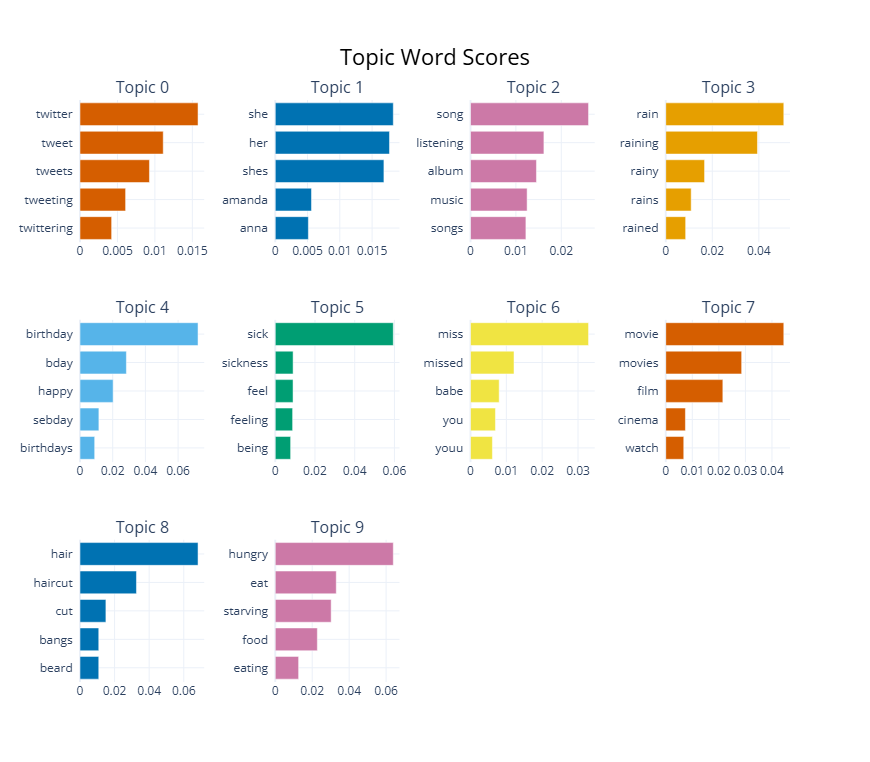

In [22]:
topicos_modelo.visualize_barchart(top_n_topics=10)

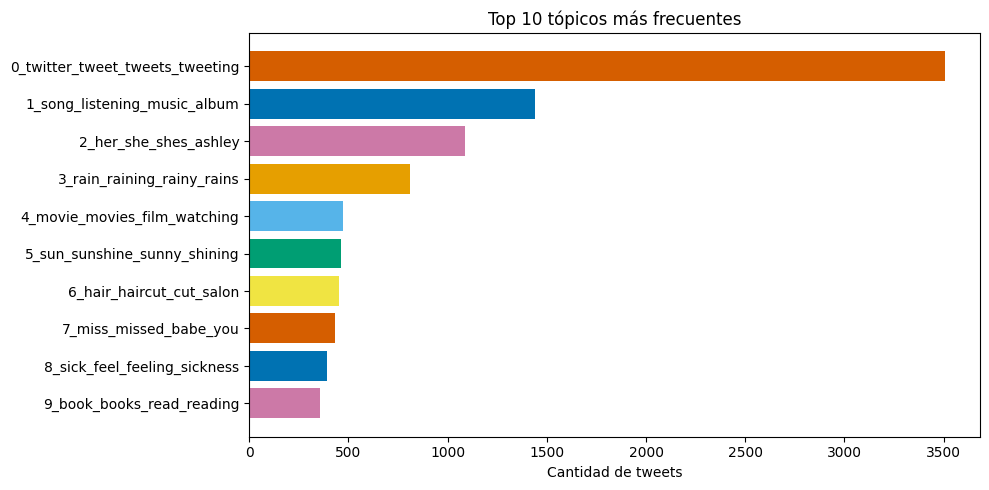

In [23]:
# Versión estática del gráfico anterior, para que se vea también en el Github
top10 = topicos[topicos["Topic"] != -1].head(10) # se excluye el -1, porque tiene los términos que no se agrupan en un tópico.

colores = colores_topicos = ["#d55e00", "#0072b2", "#cc79a7", "#e69f00", "#56b4e9", "#009e73", "#f0e442", "#d55e00", "#0072b2", "#cc79a7"]

plt.figure(figsize=(10, 5))
plt.barh(top10["Name"], top10["Count"], color=colores)
plt.xlabel("Cantidad de tweets")
plt.title("Top 10 tópicos más frecuentes")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


In [24]:
for topico_id in top10["Topic"]:
    nombre = topicos.loc[topicos["Topic"] == topico_id, "Name"].values[0]
    print(f"--- Tópico {topico_id} ({nombre}) ---")
    ejemplos = muestra.loc[muestra["topico"] == topico_id, "text"].sample(3, random_state=42)
    print("", ejemplos)
print("")

--- Tópico 0 (0_twitter_tweet_tweets_tweeting) ---
 86841    @BrandyWandLover Hehehe,  I'm going out this a...
86131    @justashley Great fun   I have 11, 9 and 6 yr ...
24923    thinks the reason i got a twitter may be the r...
Name: text, dtype: str
--- Tópico 1 (1_song_listening_music_album) ---
 8063     @jbruggers  I will check into Connie's Taqeria...
90858    TR @suranie  Will definitely keep her in my th...
26843    @acorndiggity we can take her and her boyfriend! 
Name: text, dtype: str
--- Tópico 2 (2_her_she_shes_ashley) ---
 89712    @triplejsr hmm,didnt hear &quot;i fought the w...
4242     My new trauma songs....to sing all day... are....
76419    I'm sensing a theme in this morning's musical ...
Name: text, dtype: str
--- Tópico 3 (3_rain_raining_rainy_rains) ---
 49791    @cooksons5 Hey thx so much! Yes, back in very ...
96194    I see a boring weekend ahead, rain, rain, rain...
31967    wish it would stop raining  It's June 1st!!  W...
Name: text, dtype: str
--- Tópico

In [25]:
muestra_topicos = muestra[muestra["topico"] != -1].copy()

In [26]:
tabla = pd.crosstab(muestra_topicos["topico"], muestra_topicos["sentiment"])

In [27]:
top10_topicos = muestra_topicos["topico"].value_counts().head(10).index
tabla_top = tabla.loc[top10_topicos]

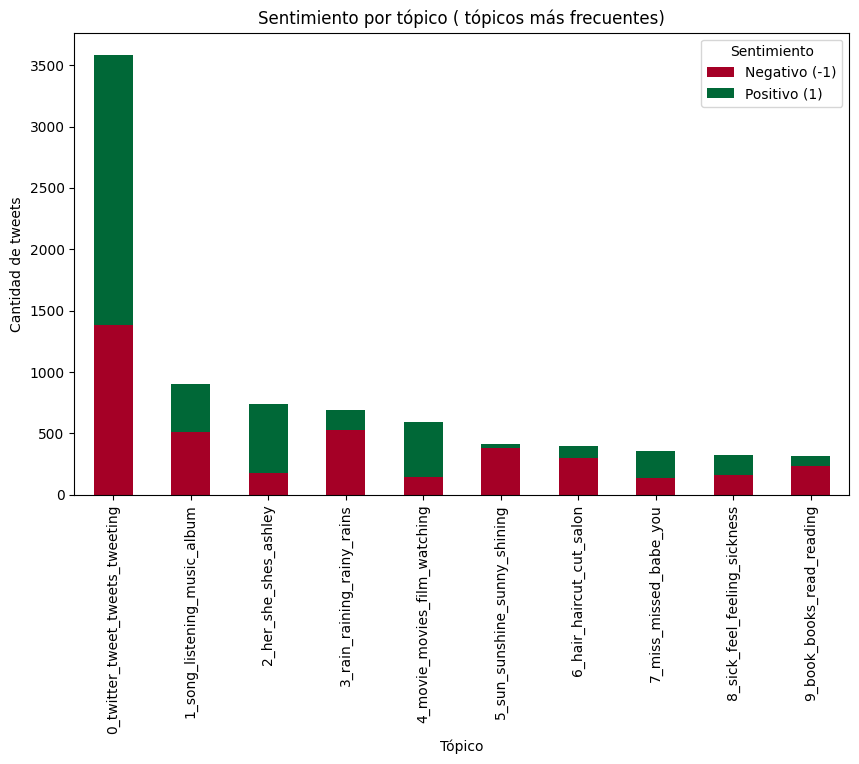

In [28]:
nombres_topico = topicos.set_index("Topic")["Name"]
tabla_top_2 = tabla_top.copy()
tabla_top_2.index = [nombres_topico[t] for t in tabla_top_2.index]

tabla_top_2.plot(kind="bar", stacked=True, figsize=(10,6), colormap="RdYlGn")
plt.title("Sentimiento por tópico ( tópicos más frecuentes)")
plt.xlabel("Tópico")
plt.ylabel("Cantidad de tweets")
plt.legend(title="Sentimiento", labels=["Negativo (-1)", "Positivo (1)"])
plt.show()